In [580]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit.quantum_info as qi
from processtensor import QTensor, QuantumState, UnitarySE, ProcessTensor, Tensor
from qiskit.visualization import plot_state_hinton
from qiskit import QuantumCircuit

import quimb.tensor as qtn

In [581]:
I = np.eye(2)
X = qi.Pauli('X').to_matrix()
Y = qi.Pauli('Y').to_matrix()
Z = qi.Pauli('Z').to_matrix()
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)

II = np.kron(I, I)
XX = np.kron(X, X)
YY = np.kron(np.conj(Y), Y)
ZZ = np.kron(Z, Z)

P = np.zeros((4, 4, 4), dtype=complex)
P[...,0] = II / 2
P[...,1] = XX / 2
P[...,2] = YY / 2
P[...,3] = ZZ / 2
P = Tensor(P)

In [582]:
def twirl_tensor(U):
    twirled = U.link_product(P, [1, 2], [0, 1])
    return twirled

def twirled_tensor_from_unitary(unitary, dS, dE):
    U = UnitarySE.from_unitary(unitary, dS, dE)
    V = twirl_tensor(U)
    return V

def calc_spectral_gap(A):
    T = np.sum(A.data, axis=2)
    evals = np.abs(np.linalg.eigvals(T))
    evals = evals / np.max(evals)
    evals = np.sort(evals)[::-1]
    gap = evals[0] - evals[1]
    return gap

def calc_correlation_length(gap):
    if gap <= 0:
        return np.inf
    else:
        return -1 / np.log(1 - gap)

In [583]:
t = np.pi / 2
circuit = QuantumCircuit(2)
circuit.rxx(t, 0, 1)
circuit.ryy(t, 0, 1)
circuit.rzz(t, 0, 1)

heisenberg_unitary = qi.Operator(circuit).data

In [584]:
dS = 2
dE = 2

random_unitary = qi.random_unitary(dS * dE).data

In [585]:
unitary = random_unitary
A = twirled_tensor_from_unitary(unitary, dS, dE)
T = np.sum(A.data, axis=2)
gap = calc_spectral_gap(A)
length = calc_correlation_length(gap)
print("Spectral gap:", gap)
print("Correlation length:", length)

Spectral gap: 0.5086533371487829
Correlation length: 1.4072508425312131


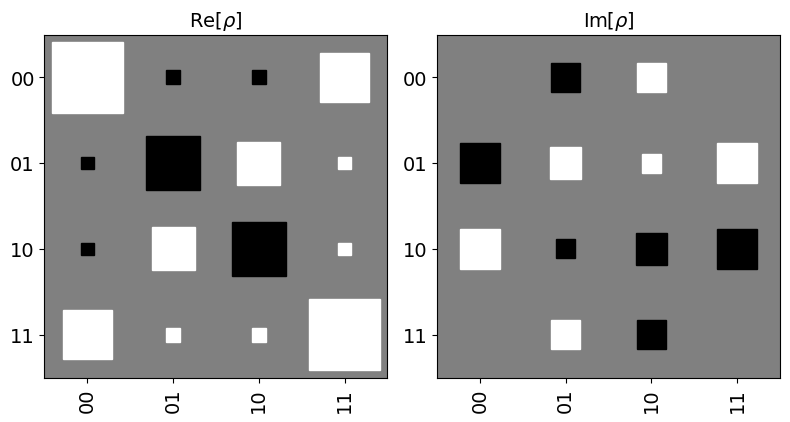

In [586]:
plot_state_hinton(T)

Text(0, 0.5, 'Transfer matrix spectral gap')

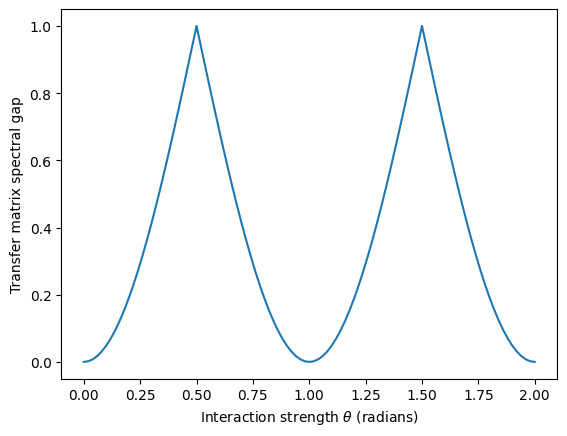

In [587]:
n = 101
X = np.linspace(0, 2, n)

gaps = []
for x in X:
    t = x * np.pi
    circuit = QuantumCircuit(2)
    circuit.rx(t, 0)
    circuit.cx(0, 1)
    # circuit.rxx(t, 0, 1)
    # circuit.ryy(t, 0, 1)
    # circuit.rzz(t, 0, 1)
    unitary = qi.Operator(circuit).data
    A = twirled_tensor_from_unitary(unitary, dS, dE)
    gap = calc_spectral_gap(A)
    gaps.append(gap)
    # print(f"x={x:.2f}, gap={gap:.6f}")

plt.plot(X, gaps)
plt.xlabel(r'Interaction strength $\theta$ (radians)')
plt.ylabel('Transfer matrix spectral gap')

In [588]:
rho_0 = np.array([[1, 0], [0, 0]])
rho_plus = np.array([[1, 1], [1, 1]]) / 2

psi_0 = np.array([1, 0])
circ = QuantumCircuit(1)
t = np.pi / 10
circ.rx(t, 0)
RX = qi.Operator(circ).data
psi_rx = RX @ psi_0
rho_rx = np.outer(psi_rx, np.conj(psi_rx))

l = QuantumState.from_matrix(rho_rx, dS=1)

circuit = QuantumCircuit(2)
t = np.pi / 2
# circuit.rxx(t, 0, 1)
# circuit.ryy(t, 0, 1)
# circuit.rzz(t, 0, 1)
circuit.cx(0, 1)
unitary = qi.Operator(circuit).data

A1 = twirled_tensor_from_unitary(unitary, dS, dE)
A1.shape
l = l.reshape(4)
A1 = l.link_product(A1, 0, 0)

A2 = twirled_tensor_from_unitary(unitary, dS, dE)
A2 = A2.reshape(4, 2, 2, 4)
A2 = A2.trace(1, 2)

S = A1.link_product(A2, 0, 0)


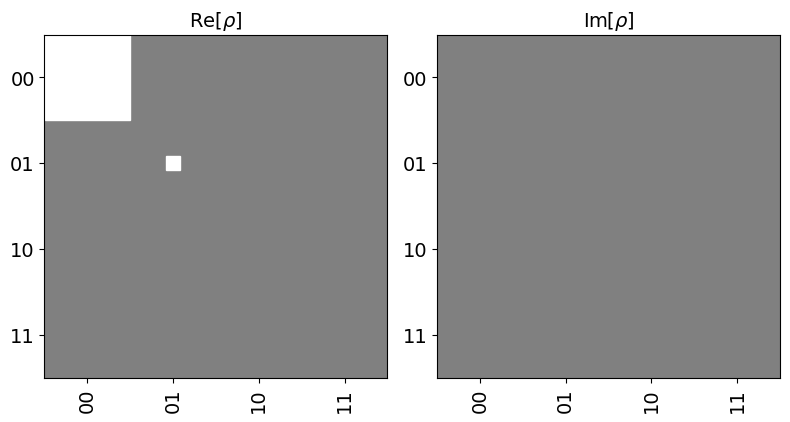

In [589]:
plot_state_hinton(S.data)